# MaxFuse usage between RNA and Protein modality on Healthy Bone Marrow data.

## Mapping the Cellular Biogeography of Human Bone Marrow Niches Using Proteomic Imaging

paper:

<https://doi.org/10.1016/j.cell.2024.04.013>

Software and source code created for this study are publicly available and can be obtained at GitHub

<https://github.com/tanlabcode/spatial-bonemarrow-atlas>

CODEX data

<https://plus.figshare.com/collections/Mapping_the_Cellular_Biogeography_of_Human_Bone_Marrow_Niches_Using_Proteomic_Imaging/7174914>

scRNA-seq data (GEO)

<https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE253355>


## max fuse
Github:

https://github.com/shuxiaoc/maxfuse

Tonsil Tutorial:

https://github.com/shuxiaoc/maxfuse/blob/main/docs/tonsil_codex_rnaseq.ipynb



In [ ]:
import numpy as np
import pandas as pd
from scipy.io import mmread

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (6, 4)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import anndata as ad
import scanpy as sc
import maxfuse as mf

import seaborn as sns

## Data preprocessing
**protein_adata**, **rna_adata**

**rna_shared**, **protein_shared**

We begin by reading in protein measurements and RNA measurements.

The file format for MaxFuse to read in is ```adata```. The original files we have for RNA was a count table (sparse matrix, row as cells column as rna), and for CODEX it was a csv file with protein expressions (row as cells column as protein). These two files can be turned into ```adata``` objects easily.

In [11]:
# read in protein data
protein = pd.read_csv("CODEX/H33_seurat_protein_expression.tsv", sep ="\t", index_col = 0) # 21,145 codex cells
protein = protein.T
protein

,CD19,ASMA,CD4,CD44,CD71,CD271,CD90,VIM,CD68,SPINK2,...,GYPC,HIF1A,MPO,OXPHOS,CD38,CD141,BCAT,PDPN,CD163,CXCR4
1_6,0.204643,0.573635,0.405356,0.186644,1.080978,0.401035,0.073827,0.347494,0.338014,0.087274,...,0.541039,0.321161,0.947175,0.368848,0.349507,0.317526,0.128623,0.294727,0.441560,0.249122
2_6,0.244123,0.673921,0.432930,0.217766,0.893133,0.406252,0.128265,0.764052,0.342043,0.201371,...,0.494404,0.322717,0.646408,0.390241,0.474819,0.338411,0.182924,0.324790,0.451604,0.272067
3_6,0.215659,0.567807,0.411560,0.051618,0.584892,0.379604,0.046575,0.255707,0.323337,0.174944,...,0.402644,0.326751,0.495694,0.319753,0.336333,0.356045,0.307501,0.346624,0.580477,0.271433
4_6,0.305459,0.755327,0.489040,0.182976,1.058616,0.473324,0.373354,1.141185,0.324879,0.120785,...,0.509793,0.319425,0.618448,0.329210,0.326492,0.623541,0.431526,0.415419,0.525297,0.278154
5_6,0.202974,0.512759,0.220524,0.047068,0.121620,0.276173,0.018894,0.281939,0.329213,0.144678,...,0.345757,0.329428,0.459786,0.311524,0.250898,0.705695,0.066527,0.194647,0.174254,0.154989
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21141_6,0.719749,0.635911,1.056556,2.946860,1.256853,2.412186,1.826007,1.212414,0.570818,0.501667,...,0.903398,0.314541,0.330091,0.723527,0.630597,0.565196,1.336616,0.555203,1.365861,1.030482
21142_6,0.596963,0.546984,0.540200,2.717697,1.059699,1.693974,1.690324,0.902313,0.444507,0.746871,...,0.821838,0.335420,0.303638,0.774074,1.181745,0.641120,1.120353,0.649433,0.933184,1.092915
21143_6,0.372661,1.170255,0.320701,0.543387,1.608897,0.529450,0.856419,1.070718,0.373820,0.316880,...,1.064983,0.323564,0.469780,0.525533,0.349312,0.423802,0.978464,0.824585,0.270098,0.464098
21144_6,0.640994,0.673986,0.746098,2.788410,1.239104,1.856994,1.836283,1.129397,0.506380,0.772881,...,1.018972,0.314156,0.331183,0.709343,1.332509,0.648149,1.287227,0.708494,0.992127,0.966707


In [157]:
# convert to AnnData
protein_adata = ad.AnnData(
    protein.to_numpy(), dtype=np.float32
)
protein_adata.var_names = protein.columns
protein_adata.obs_names = protein.index
protein_adata

AnnData object with n_obs × n_vars = 21145 × 49

Then we read in the RNA files and convert to ```adata``` format too.

In [14]:
# read in RNA data
rna = pd.read_csv("scRNAseq/H33_seurat_rna_expression_count.tsv", sep ="\t", index_col = 0) # rna count as sparse matrix, 10k cells (RNA)
rna = rna.T
rna 

,AL627309.1,AC114498.1,AL669831.2,AL669831.5,FAM87B,LINC00115,FAM41C,AL645608.7,AL645608.3,AL645608.1,...,AL031674.1,LINC00904,PTH2,KLK6,TMEM190,Z99755.2,SMIM34B,OLIG2,AF064858.2,LINC00111
H33_AAACCCAGTGTACAGG-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
H33_AAACCCAGTTCACCGG-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
H33_AAACCCATCGACCACG-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
H33_AAACGAAAGAGCAACC-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
H33_AAACGAAAGAGGTGCT-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
H33_TTTGTTGGTGGATCAG-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
H33_TTTGTTGTCAGCAATC-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
H33_TTTGTTGTCCACTTCG-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
H33_TTTGTTGTCCGATGTA-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [155]:
# convert to AnnData
rna_adata = ad.AnnData(
    rna.to_numpy(), dtype=np.float32
)
rna_adata.var_names = rna.columns
rna_adata.obs_names = rna.index
rna_adata

AnnData object with n_obs × n_vars = 6737 × 29452

In [161]:
cell_annotations = pd.read_csv("scRNAseq/H33_cell_annotation.tsv", sep = '\t', index_col=0)
cell_annotations

,DONOR,nCount_RNA,nFeature_RNA,percent.mt,cluster_anno_l2,cluster_anno_coarse,cluster_anno_l1,Sex,Age,Ethnicity
H33_AAACCCAGTGTACAGG-1,H33,17687,4331,3.341437,GMP,Hematopoietic,HSPC,Male,74,Caucasian
H33_AAACCCAGTTCACCGG-1,H33,2088,1311,4.166667,MPP,Hematopoietic,HSPC,Male,74,Caucasian
H33_AAACCCATCGACCACG-1,H33,82991,7111,7.462255,Erythroblast,Hematopoietic,Meg/E,Male,74,Caucasian
H33_AAACGAAAGAGCAACC-1,H33,5644,1935,5.297661,Monocyte,Hematopoietic,Myeloid,Male,74,Caucasian
H33_AAACGAAAGAGGTGCT-1,H33,14300,2952,0.055944,Erythroblast,Hematopoietic,Meg/E,Male,74,Caucasian
...,...,...,...,...,...,...,...,...,...,...
H33_TTTGTTGGTGGATCAG-1,H33,1075,557,0.093023,Erythroblast,Hematopoietic,Meg/E,Male,74,Caucasian
H33_TTTGTTGTCAGCAATC-1,H33,15833,3254,3.896924,Plasma Cell,Hematopoietic,Lymphoid,Male,74,Caucasian
H33_TTTGTTGTCCACTTCG-1,H33,15697,3367,2.554628,Monocyte,Hematopoietic,Myeloid,Male,74,Caucasian
H33_TTTGTTGTCCGATGTA-1,H33,3297,1662,3.245375,MPP,Hematopoietic,HSPC,Male,74,Caucasian


In [162]:
# check for cell_id ordering consistency, expect True
all(rna_adata.obs_names == cell_annotations.index)

True

In [165]:
rna_adata.obs = cell_annotations
rna_adata

AnnData object with n_obs × n_vars = 6737 × 29452
    obs: 'DONOR', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'cluster_anno_l2', 'cluster_anno_coarse', 'cluster_anno_l1', 'Sex', 'Age', 'Ethnicity'

In [166]:
protein_adata.var_names, rna_adata.var_names

(Index(['CD19', 'ASMA', 'CD4', 'CD44', 'CD71', 'CD271', 'CD90', 'VIM', 'CD68',
        'SPINK2', 'CD117', 'CD45RA', 'FOXC1', 'CD61', 'CD45', 'CD8', 'CD49F',
        'CD11C', 'VECAD', 'CD15', 'CD123', 'CD138', 'CD14', 'PLP1', 'CD11B',
        'HLA-DR', 'CD34', 'CD79A', 'CD10', 'PAX5', 'MastCellTryptase', 'TGFB1',
        'VCAM1', 'CD146', 'CD3e', 'CD33', 'GATA1', 'CXCL12', 'BCL2', 'GYPC',
        'HIF1A', 'MPO', 'OXPHOS', 'CD38', 'CD141', 'BCAT', 'PDPN', 'CD163',
        'CXCR4'],
       dtype='object'),
 Index(['AL627309.1', 'AC114498.1', 'AL669831.2', 'AL669831.5', 'FAM87B',
        'LINC00115', 'FAM41C', 'AL645608.7', 'AL645608.3', 'AL645608.1',
        ...
        'AL031674.1', 'LINC00904', 'PTH2', 'KLK6', 'TMEM190', 'Z99755.2',
        'SMIM34B', 'OLIG2', 'AF064858.2', 'LINC00111'],
       dtype='object', length=29452))

Here we are integrating protein and RNA data, and most of the time there are name differences between protein (antibody) and their corresponding gene names. 

These "weak linked" features will be used during initialization (we construct two arrays, `rna_shared` and `protein_shared`, whose columns are matched, and the two arrays can be used to obtain the initial matching). 

To construct the feature correspondence in straight forward way, we prepared a ```.csv``` file containing most of the antibody name (seen in cite-seq or codex antibody names etc) and their corresponding gene names:


In [86]:
correspondence = pd.read_csv('protein_gene_conversion.csv')
correspondence.head()

,Protein name,RNA name
0,CD19,CD19
1,ASMA,ACTA2
2,CD4,CD4
3,CD44,CD44/CD44-AS1
4,CD71,TFRC


But of course this files does not contain all names including custom names in new assays. If a certain correspondence is not found, either it is missing in the other modality, or you should customly add the name conversion to this ```.csv``` file.

In [ ]:
rna_protein_correspondence = []

for i in range(correspondence.shape[0]):
    curr_protein_name, curr_rna_names = correspondence.iloc[i]
    if curr_protein_name not in protein_adata.var_names:
        continue
    if curr_rna_names.find('Ignore') != -1: # some correspondence ignored eg. protein isoform to one gene
        continue
    curr_rna_names = curr_rna_names.split('/') # eg. one protein to multiple genes
    for r in curr_rna_names:
        if r in rna_adata.var_names:
            rna_protein_correspondence.append([r, curr_protein_name])
            
rna_protein_correspondence = np.array(rna_protein_correspondence)
rna_protein_correspondence, len(rna_protein_correspondence)

In [92]:
# Columns rna_shared and protein_shared are matched.
# One may encounter "Variable names are not unique" warning,
# this is fine and is because one RNA may encode multiple proteins and vice versa.
rna_shared = rna_adata[:, rna_protein_correspondence[:, 0]].copy()
protein_shared = protein_adata[:, rna_protein_correspondence[:, 1]].copy()
rna_shared, protein_shared

/home/ubuntu/singlecellenv/lib/python3.10/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/ubuntu/singlecellenv/lib/python3.10/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


(AnnData object with n_obs × n_vars = 6737 × 50,
 AnnData object with n_obs × n_vars = 21145 × 50)

Then we retrieve the shared features. Normally we should not use all the shared featues, as some of the shared feature RNA are not very variable, and inputing low quality features could potentially decrease the performance of ```MaxFuse```. In this case we only use RNA or Protein features that are variable (larger than a certain threshold).

In [103]:
# Make sure no column is static
mask = (
    (rna_shared.X.std(axis=0) > 0.5) 
    & (protein_shared.X.std(axis=0) > 0.1)
)
rna_shared = rna_shared[:, mask].copy()
protein_shared = protein_shared[:, mask].copy()
rna_shared.shape, protein_shared.shape

/home/ubuntu/singlecellenv/lib/python3.10/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/ubuntu/singlecellenv/lib/python3.10/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


((6737, 35), (21145, 35))

We apply standard Scanpy preprocessing steps to `rna_shared`.
We skipped the processing steps for `protein_shared` because the input CODEX data was already normalized et.

In [104]:
# process rna_shared
sc.pp.normalize_total(rna_shared)
sc.pp.log1p(rna_shared)
sc.pp.scale(rna_shared)


/home/ubuntu/singlecellenv/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:197: UserWarning: Some cells have zero counts
  warn(UserWarning('Some cells have zero counts'))


In [105]:
# plot UMAP of rna cells based only on rna markers with protein correspondence

sc.pp.neighbors(rna_shared, n_neighbors=15)
sc.tl.umap(rna_shared)
#sc.pl.umap(rna_shared, color='celltype')

In [14]:
# plot UMAPs of codex cells based only on protein markers with rna correspondence
# due to a large number of codex cells, this can take a while. uncomment below to plot.

# sc.pp.neighbors(protein_shared, n_neighbors=15)
# sc.tl.umap(protein_shared)
# sc.pl.umap(protein_shared, color='celltype')

In [106]:
rna_shared = rna_shared.X.copy()
protein_shared = protein_shared.X.copy()

We again apply standard Scanpy preprocessing steps to **all available RNA measurements and protein measurements** (not just the shared ones) to get two arrays, `rna_active` and `protein_active`, which are used for iterative refinement. Again if the input data is already processed, these steps can be skipped.

In [107]:
# process all RNA features
sc.pp.normalize_total(rna_adata)
sc.pp.log1p(rna_adata)
sc.pp.highly_variable_genes(rna_adata, n_top_genes=5000)
# only retain highly variable genes
rna_adata = rna_adata[:, rna_adata.var.highly_variable].copy()
sc.pp.scale(rna_adata)

/home/ubuntu/singlecellenv/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:216: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby('mean_bin')['dispersions']


In [ ]:
# plot UMAPs of rna cells based on all active rna markers

sc.pp.neighbors(rna_adata, n_neighbors=15)
sc.tl.umap(rna_adata)
sc.pl.umap(rna_adata, color='celltype')

In [18]:
# plot UMAPs of protein cells based on all active protein markers
# due to a large number of codex cells, this can take a while. uncomment below to plot.

# sc.pp.neighbors(protein_adata, n_neighbors=15)
# sc.tl.umap(protein_adata)
# sc.pl.umap(protein_adata, color='celltype')

In [108]:
# make sure no feature is static
rna_active = rna_adata.X
protein_active = protein_adata.X
rna_active = rna_active[:, rna_active.std(axis=0) > 1e-5] # these are fine since already using variable features
protein_active = protein_active[:, protein_active.std(axis=0) > 1e-5] # protein are generally variable

In [109]:
# inspect shape of the four matrices
print(rna_active.shape)
print(protein_active.shape)
print(rna_shared.shape)
print(protein_shared.shape)

(6737, 5000)
(21145, 49)
(6737, 35)
(21145, 35)


## Fitting MaxFuse

### Step I: preparations

We now have four arrays. `rna_shared` and `protein_shared` are used for finding initial pivots, whereas `rna_active` and `protein_active` are used for iterative refinement. 

The main object for running MaxFuse pipeline is `mf.model.Fusor`, and its constructor takes the above four arrays as input.

If your data have not been clustered and annotated, you can leave `labels1` and `labels2` to be `None`, then MaxFuse will automatically run clustering algorithms to fill them in.

**Optional**: If your data have already been clustered (and you trust your annotation is optimal and should be used to guide the MaxFuse smoothing steps), you could supply them as ```numpy``` arrays to `labels1` and `labels2`.

In [110]:
# call constructor for Fusor object
# which is the main object for running MaxFuse pipeline
fusor = mf.model.Fusor(
    shared_arr1=rna_shared,
    shared_arr2=protein_shared,
    active_arr1=rna_active,
    active_arr2=protein_active,
    labels1=None,
    labels2=None
)

To reduce computational complexity, we call `split_into_batches` to fit the batched version of MaxFuse.

Internally, MaxFuse will solve a few linear assignment problems of size $n_1 \times n_2$, where $n_1$ and $n_2$ (with $n_1\leq n_2$ by convention) are the sample sizes of the two modalities (after batching and metacell construction).
`max_outward_size` specifis the maximum value of $n_1$.

`matching_ratio` specifies approximately the ratio of $n_2/n_1$.
The larger it is, the more candidate cells in the second modality MaxFuse will seek for to match each cell/metacell in the first modality.

`metacell_size` specifies the average size of the metacells in the first modality.

Since this integration process is larger (more CODEX cells), we could increase the `max_outward_size` as long as the memory can accomodate that.

In [111]:
fusor.split_into_batches(
    max_outward_size=8000,
    matching_ratio=4,
    metacell_size=2,
    verbose=True
)

The first data is split into 1 batches, average batch size is 6737, and max batch size is 6737.
The second data is split into 1 batches, average batch size is 21145, and max batch size is 21145.
Batch to batch correspondence is:
  ['0<->0'].


The next step is to construct appropriate nearest-neighbor graphs for each modality with all features available.
But before that, we plot the singular values of the two active arrays to determine how many principal components (PCs) to keep when doing graph construction.

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Singular value v.s. component index for batch 0'}, xlabel='Index', ylabel='Singular value'>)

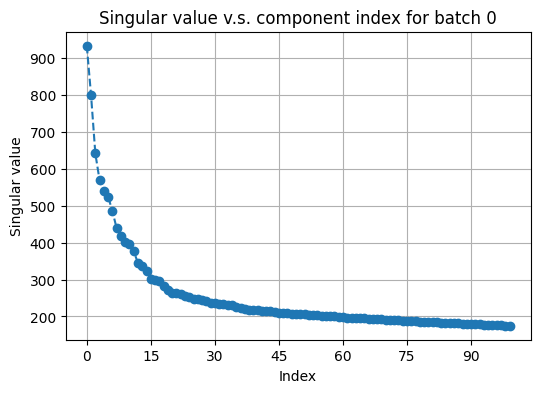

In [112]:
# plot top singular values of avtive_arr1 on a random batch
fusor.plot_singular_values(
    target='active_arr1',
    n_components=None # can also explicitly specify the number of components
)

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Singular value v.s. component index for batch 0'}, xlabel='Index', ylabel='Singular value'>)

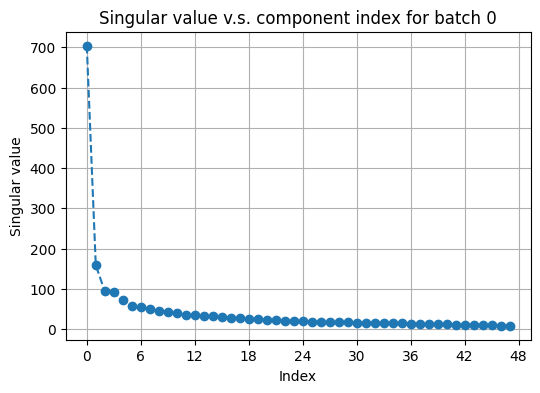

In [113]:
# plot top singular values of avtive_arr2 on a random batch
fusor.plot_singular_values(
    target='active_arr2',
    n_components=None
)

Inspecting the "elbows", we choose the number of PCs to be **40** for both RNA and  **15** for protein active data.
We then call `construct_graphs` to compute nearest-neighbor graphs as needed.

In [114]:
fusor.construct_graphs(
    n_neighbors1=15,
    n_neighbors2=15,
    svd_components1=40,
    svd_components2=15,
    resolution1=2,
    resolution2=2,
    # if two resolutions differ less than resolution_tol
    # then we do not distinguish between then
    resolution_tol=0.1,
    verbose=True
)

Aggregating cells in arr1 into metacells of average size 2...
Constructing neighborhood graphs for cells in arr1...
Now at batch 0...
Graph construction finished!
Clustering into metacells...
Now at batch 0...
Metacell clustering finished!
Constructing neighborhood graphs for cells in arr1...
Now at batch 0...
Graph construction finished!
Clustering the graphs for cells in arr1...
Now at batch 0...
Graph clustering finished!
Constructing neighborhood graphs for cells in arr2...
Now at batch 0...
Graph construction finished!
Clustering the graphs for cells in arr2...
Now at batch 0...
Graph clustering finished!


### Step II: finding initial pivots

We then use shared arrays whose columns are matched to find initial pivots.
Before we do so, we plot top singular values of two shared arrays to determine how many PCs to use.

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Singular value v.s. component index for batch 0'}, xlabel='Index', ylabel='Singular value'>)

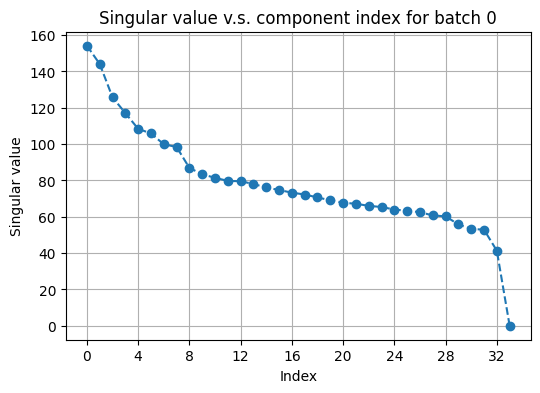

In [115]:
# plot top singular values of shared_arr1 on a random batch
fusor.plot_singular_values(
    target='shared_arr1',
    n_components=None,
)

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Singular value v.s. component index for batch 0'}, xlabel='Index', ylabel='Singular value'>)

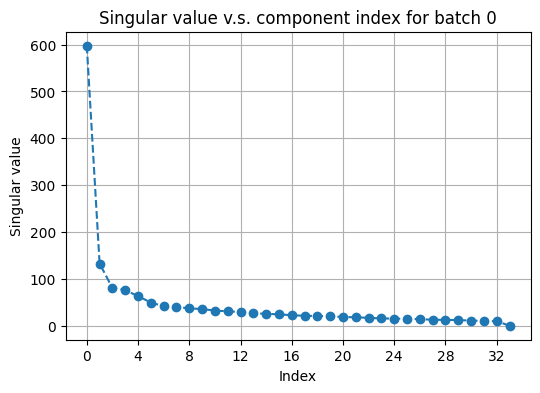

In [116]:
# plot top singular values of shared_arr2 on a random batch
fusor.plot_singular_values(
    target='shared_arr2',
    n_components=None
)

We choose to use **25** PCs for ``rna_shared`` and **20** PCs for ``protein_shared``.

We then call ``find_initial_pivots`` to compute initial set of matched pairs.
In this function, ``wt1`` (resp. ``wt2``) is a number between zero and one that specifies the weight on the smoothing target for the first (resp. second) modality. 
The smaller it is, the greater the strength of fuzzy smoothing.
When the weight is one, then there is no smoothing at all, meaning the original data will be used.

Previously in the **cite-seq** example we used ``wt1 = 0.7`` and ``wt2 = 0.7``. In the case of integration that involves **spatial** data, we encourage using ``wt1 = 0.3`` and ``wt2 = 0.3`` since such datasets are usually "weaker" in linkage and requires stronger "smoothing".

In [117]:
fusor.find_initial_pivots(
    wt1=0.3, wt2=0.3,
    svd_components1=25, svd_components2=20
)

Now at batch 0<->0...
Done!


Now, we have a set of *initial pivots* that store the matched pairs when only the information in the shared arrays is used. The information on initial pivots are stored in the internal field ``fusor._init_matching`` that is invisible to users.

### Step III: finding refined pivots

We now use the information in active arrays to iteratively refine initial pivots.
We plot the top canonical correlations to choose the best number of components in canonical correlation analysis (CCA).

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Canonical correlation v.s. component index for batch 0<->0'}, xlabel='Index', ylabel='Canonical correlation'>)

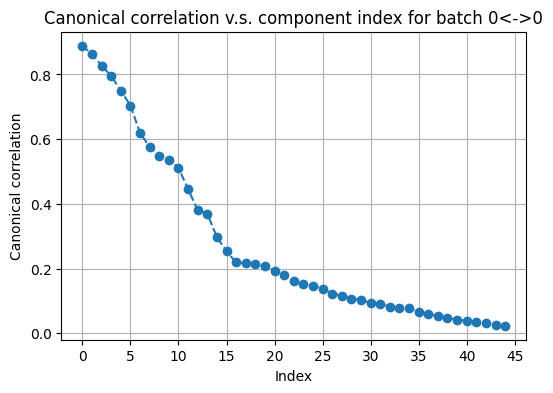

In [118]:
# plot top canonical correlations in a random batch
fusor.plot_canonical_correlations(
    svd_components1=50,
    svd_components2=None,
    cca_components=45
)

A quick check on the previous plot gives a rough guide on what the `refine_pivots` parameters should be picked.

**Note:** here that the `n_iters` number we choosed *1*, as in low snr datasets (eg. Spatial-omis) increase amount of iteration might degrade the performance.

In [119]:
fusor.refine_pivots(
    wt1=0.3, wt2=0.3,
    svd_components1=40, svd_components2=None,
    cca_components=25,
    n_iters=1,
    randomized_svd=False, 
    svd_runs=1,
    verbose=True
)

Now at batch 0<->0...
Done!


**Note:** here we can see `filter_prop` we increased the pivot filtering to *0.5* compared to previous example. We found harsher filtering for integrations that involves spatial-omics is more beneficial.

In [120]:
fusor.filter_bad_matches(target='pivot', filter_prop=0.5)

Begin filtering...
Now at batch 0<->0...
1677/3354 pairs of matched cells remain after the filtering.
Fitting CCA on pivots...
Scoring matched pairs...
3282/6737 cells in arr1 are selected as pivots.
1677/21145 cells in arr2 are selected as pivots.
Done!


**Optional:** quick check the performance based on cell type accuracy (pivot matching).

In [32]:
pivot_matching = fusor.get_matching(order=(2, 1),target='pivot')

lv1_acc = mf.metrics.get_matching_acc(matching=pivot_matching, 
    labels1=labels_rna, 
    labels2=labels_codex,
    order = (2,1)
)
lv1_acc

0.9553428042001235

In [33]:
# We can inspect the first pivot pair.
[pivot_matching[0][0], pivot_matching[1][0], pivot_matching[2][0]]

[3249, 13, 0.8213132906237305]

**Note:** Since we have the `refine_pivots` now, we can theoratically co-embedding the *full* dataset into CCA space (as described in `tutorial-1`). **However**, in the case that invovles *low-snr* datasets (eg. spatial-omics), we do not suggest projecting all the cells into a common space without any filtering steps. We will describe this process after the `propogation` step.

### Step IV: propagation

Refined pivots can only give us a pivot matching that captures a subset of cells. In order to get a *full* matching that involves all cells during input, we need to call `propagate`.


In [121]:
fusor.propagate(
    svd_components1=40, 
    svd_components2=None, 
    wt1=0.7,
    wt2=0.7,
)

Now at batch 0<->0...
Done!


We call `filter_bad_matches` with `target=propagated` to optionally filter away a few matched pairs from propagation. 

**Note:** In the best scenario, we would prefer all cells in the *full* dataset can be matched accross modality. However, in the case that invovles *low-snr* datasets (eg. spatial-omics), many cells are noisy (or lack of information) and should not be included in downstream cross-modality analysis. We suggest in such scenarios, `filter_prop` should be set around *0.1-0.4*.

In [122]:
fusor.filter_bad_matches(
    target='propagated',
    filter_prop=0.3
)

Begin filtering...
Now at batch 0<->0...
14801/21145 pairs of matched cells remain after the filtering.
Scoring matched pairs...
Done!


We use `get_matching` with `target='full_data'` to extract the full matching.

Because of the batching operation, the resulting matching may contain duplicates. The `order` argument determines how those duplicates are dealt with. 
`order=None` means doing nothing and returning the matching with potential duplicates;
`order=(1, 2)` means returning a matching where each cell in the first modality contains *at least one match* in the second modality;
`order=(2, 1)` means returning a matching where each cell in the second modality contains *at least one match* in the first modality.

**Note:** Since we filtered out some cell pairs here, not all cells in the full dataset has matches.

In [123]:
full_matching = fusor.get_matching(order=(2, 1), target='full_data')

Since we are doing `order=(2, 1)` here, the matching info is all the cells (10k) in mod 2 (protein) has at least one match cell in the RNA modality. Note that the matched cell in RNA could be duplicated, as protein cells could be matched to the same RNA cell. For a quick check on matching format:

In [139]:
matchResult = pd.DataFrame(list(zip(full_matching[0], full_matching[1], full_matching[2])), 
             columns = ['mod1_indx', 'mod2_indx', 'score'])
matchResult
# columns: cell idx in mod1, cell idx in mod2, and matching scores

,mod1_indx,mod2_indx,score
0,1563,8,0.697536
1,5233,9,0.654984
2,264,17,0.786861
3,2404,45,0.741476
4,3270,59,0.542900
...,...,...,...
16473,1194,21121,0.341803
16474,1194,21122,0.456326
16475,1194,21126,0.363176
16476,1194,21129,0.511103


In [174]:
rna_adata.obs

,DONOR,nCount_RNA,nFeature_RNA,percent.mt,cluster_anno_l2,cluster_anno_coarse,cluster_anno_l1,Sex,Age,Ethnicity
H33_AAACCCAGTGTACAGG-1,H33,17687,4331,3.341437,GMP,Hematopoietic,HSPC,Male,74,Caucasian
H33_AAACCCAGTTCACCGG-1,H33,2088,1311,4.166667,MPP,Hematopoietic,HSPC,Male,74,Caucasian
H33_AAACCCATCGACCACG-1,H33,82991,7111,7.462255,Erythroblast,Hematopoietic,Meg/E,Male,74,Caucasian
H33_AAACGAAAGAGCAACC-1,H33,5644,1935,5.297661,Monocyte,Hematopoietic,Myeloid,Male,74,Caucasian
H33_AAACGAAAGAGGTGCT-1,H33,14300,2952,0.055944,Erythroblast,Hematopoietic,Meg/E,Male,74,Caucasian
...,...,...,...,...,...,...,...,...,...,...
H33_TTTGTTGGTGGATCAG-1,H33,1075,557,0.093023,Erythroblast,Hematopoietic,Meg/E,Male,74,Caucasian
H33_TTTGTTGTCAGCAATC-1,H33,15833,3254,3.896924,Plasma Cell,Hematopoietic,Lymphoid,Male,74,Caucasian
H33_TTTGTTGTCCACTTCG-1,H33,15697,3367,2.554628,Monocyte,Hematopoietic,Myeloid,Male,74,Caucasian
H33_TTTGTTGTCCGATGTA-1,H33,3297,1662,3.245375,MPP,Hematopoietic,HSPC,Male,74,Caucasian


## Step V: export results

In [179]:
# export full matching results
matchResult["protein_id"] = protein_adata.obs_names[matchResult.mod2_indx].values
matchResult["scRNA_cluster_anno_coarse"]= rna_adata.obs["cluster_anno_coarse"][matchResult.mod1_indx].values
matchResult["scRNA_cluster_anno_l1"]= rna_adata.obs["cluster_anno_l1"][matchResult.mod1_indx].values
matchResult["scRNA_cluster_anno_l2"]= rna_adata.obs["cluster_anno_l2"][matchResult.mod1_indx].values
matchResult.set_index("protein_id", inplace=True)
matchResult

/tmp/ipykernel_2125498/1978183872.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  matchResult["scRNA_cluster_anno_coarse"]= rna_adata.obs["cluster_anno_coarse"][matchResult.mod1_indx].values
/tmp/ipykernel_2125498/1978183872.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  matchResult["scRNA_cluster_anno_l1"]= rna_adata.obs["cluster_anno_l1"][matchResult.mod1_indx].values
/tmp/ipykernel_2125498/1978183872.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by 

,mod1_indx,mod2_indx,score,scRNA_cluster_anno_coarse,scRNA_cluster_anno_l1,scRNA_cluster_anno_l2
protein_id,,,,,,
9_6,1563,8,0.697536,Hematopoietic,HSPC,HSC
10_6,5233,9,0.654984,Hematopoietic,HSPC,HSC
18_6,264,17,0.786861,Hematopoietic,Lymphoid,CD4+ T-Cell
46_6,2404,45,0.741476,Hematopoietic,HSPC,HSC
60_6,3270,59,0.542900,Hematopoietic,Lymphoid,Plasma Cell
...,...,...,...,...,...,...
21122_6,1194,21121,0.341803,Hematopoietic,HSPC,GMP
21123_6,1194,21122,0.456326,Hematopoietic,HSPC,GMP
21127_6,1194,21126,0.363176,Hematopoietic,HSPC,GMP


In [180]:
matchResult.to_csv('scRNAseqToCodex.tsv', sep="\t")

### Step V: downstream analysis (not done)

As mentioned before, we want to draw a UMAP in the joint-embedding space, but for the filtered version of cells. For the *low-snr* datasets (eg. spatial-omics), we suggest only using cells that survived the propogation filtering step.

In [40]:
rna_cca, protein_cca_sub = fusor.get_embedding(
    active_arr1=fusor.active_arr1,
    active_arr2=fusor.active_arr2[full_matching[1],:] # cells in codex remained after filtering
)

Since we have *~170,000* cells for CODEX, calculating UMAP for the full dataset will take a while, for showcasing we can just subsample a smaller sample.

In [41]:
np.random.seed(42)
subs = 13000
randix = np.random.choice(protein_cca_sub.shape[0],subs, replace = False)

dim_use = 15 # dimensions of the CCA embedding to be used for UMAP etc

cca_adata = ad.AnnData(
    np.concatenate((rna_cca[:,:dim_use], protein_cca_sub[randix,:dim_use]), axis=0), 
    dtype=np.float32
)
cca_adata.obs['data_type'] = ['rna'] * rna_cca.shape[0] + ['protein'] * subs
cca_adata.obs['cell_type'] = list(np.concatenate((labels_rna,
                                                  labels_codex[full_matching[1]][randix]), axis = 0))

/Users/zongming/miniconda3/envs/maxfuse_ipynb/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


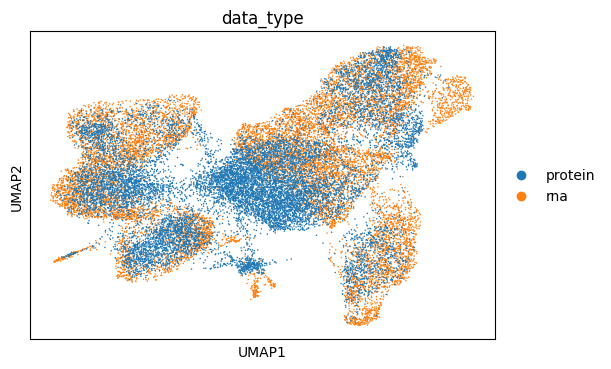

In [42]:
sc.pp.neighbors(cca_adata, n_neighbors=15)
sc.tl.umap(cca_adata)
sc.pl.umap(cca_adata, color='data_type')

/Users/zongming/miniconda3/envs/maxfuse_ipynb/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


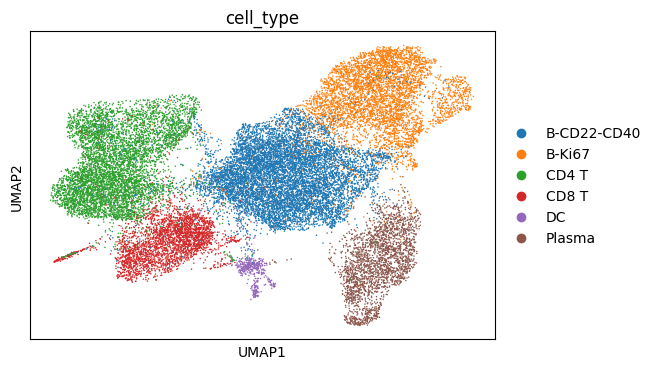

In [43]:
sc.pl.umap(cca_adata, color='cell_type')

### Step VI: more custom analysis

There could be potentially more custom analysis produced by `MaxFuse`. 

For example in our manuscript, we looked at the distribution or RNA counts on a CODEX tissue. Such information can be directly retrieved from the `full_matching` table we produced previously (eg. transfer the RNA information onto CODEX for each matched single cell pair). 

Moreover, analysis like label transfer can also be implemented, either by directly transfering the labels across matched pairs, or run a *KNN* process on the joint-embedding that `MaxFuse` produced, and do *majority voting*, or some kind of *weighted decision* based on the distance scores from `MaxFuse`. 

Since these type of analysis are highly customized, we did not implment them in the `MaxFuse` pipeline. However, please give us feedbacks on whether a specific type of task should be included.